In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
def roc_auc():
    return roc_auc_score(y_test, clf.predict_proba(X_test) , multi_class='ovo')

In [3]:
df = pd.read_csv("morganFP_1024.csv")
df

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
756,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
757,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
758,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df_class = pd.read_csv("ido_tdo.csv" , index_col=0)
df_class

,ido_tdo
0,AA
1,II
2,AI
3,II
4,II
...,...
755,II
756,II
757,IA
758,AI


In [5]:
y = df_class.iloc[:,-1]
y

0      AA
1      II
2      AI
3      II
4      II
       ..
755    II
756    II
757    IA
758    AI
759    AA
Name: ido_tdo, Length: 760, dtype: object

In [6]:
X = df.iloc[:, :]
X

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
756,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
757,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
758,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
from sklearn.manifold import TSNE

In [8]:
X_reduced = TSNE(random_state=42).fit_transform(X)

In [9]:
X_reduced

array([[  0.44940272, -24.452404  ],
       [-23.72359   ,  -7.5131435 ],
       [ -1.0644954 , -23.82095   ],
       ...,
       [-23.64101   ,  -8.3261385 ],
       [ -0.38524967,   4.171037  ],
       [ -0.21525514, -23.772568  ]], shape=(760, 2), dtype=float32)

In [10]:
from sklearn.preprocessing import LabelEncoder

In [15]:
y = LabelEncoder().fit_transform(y)

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced,y, stratify=y, random_state=42 , test_size=0.2)

In [18]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42, probability=True)

In [19]:
clf.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [20]:
ypred = clf.predict(X_test)

In [24]:
print(classification_report(y_test , ypred))
print(confusion_matrix(y_test , ypred))
roc_auc()

              precision    recall  f1-score   support

           0       0.63      0.62      0.63        42
           1       0.79      0.68      0.73        34
           2       0.26      0.62      0.36        16
           3       0.70      0.50      0.58        60

    accuracy                           0.59       152
   macro avg       0.60      0.61      0.58       152
weighted avg       0.66      0.59      0.60       152

[[26  4  9  3]
 [ 5 23  0  6]
 [ 2  0 10  4]
 [ 8  2 20 30]]


np.float64(0.8390085200746965)

### now with PCA

In [29]:
from sklearn.decomposition import PCA

In [31]:
X_reduced = PCA(n_components=2, random_state=42).fit_transform(X)

In [32]:
X_reduced

array([[-1.70936678, -1.3488452 ],
       [-1.61290213, -0.25216479],
       [-1.22016108, -1.06368842],
       ...,
       [-2.13538632, -0.69930308],
       [ 0.8768404 , -0.62828502],
       [-1.6364037 , -0.67639736]], shape=(760, 2))

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced,y, stratify=y, random_state=42 , test_size=0.2)

In [35]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42, probability=True)

In [36]:
clf.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [37]:
ypred = clf.predict(X_test)

In [38]:
print(classification_report(y_test , ypred))
print(confusion_matrix(y_test , ypred))
roc_auc()

              precision    recall  f1-score   support

           0       0.67      0.48      0.56        42
           1       0.53      0.71      0.61        34
           2       0.24      0.50      0.33        16
           3       0.68      0.50      0.58        60

    accuracy                           0.54       152
   macro avg       0.53      0.55      0.52       152
weighted avg       0.60      0.54      0.55       152

[[20  9 11  2]
 [ 3 24  0  7]
 [ 3  0  8  5]
 [ 4 12 14 30]]


np.float64(0.8057500778089014)

### now with umap

In [39]:
import umap

/run/media/rafe/volume D/Documents/new_chminformatic_project/cheminformatic_project_1_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
X_reduced = umap.UMAP(random_state=42).fit_transform(X)

/run/media/rafe/volume D/Documents/new_chminformatic_project/cheminformatic_project_1_venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced,y, stratify=y, random_state=42 , test_size=0.2)

In [43]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42, probability=True)

In [44]:
clf.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [45]:
ypred = clf.predict(X_test)

In [46]:
print(classification_report(y_test , ypred))
print(confusion_matrix(y_test , ypred))
roc_auc()

              precision    recall  f1-score   support

           0       0.73      0.45      0.56        42
           1       0.95      0.59      0.73        34
           2       0.23      0.62      0.33        16
           3       0.69      0.70      0.69        60

    accuracy                           0.60       152
   macro avg       0.65      0.59      0.58       152
weighted avg       0.71      0.60      0.63       152

[[19  0 19  4]
 [ 5 20  0  9]
 [ 0  0 10  6]
 [ 2  1 15 42]]


np.float64(0.7971363892779335)

### with pacmap

In [49]:
import pacmap

In [51]:
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0 , random_state=42) 

In [52]:
X_reduced = embedding.fit_transform(X)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced,y, stratify=y, random_state=42 , test_size=0.2)

In [54]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42, probability=True)

In [55]:
clf.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [56]:
ypred = clf.predict(X_test)

In [57]:
print(classification_report(y_test , ypred))
print(confusion_matrix(y_test , ypred))
roc_auc()

              precision    recall  f1-score   support

           0       0.76      0.60      0.67        42
           1       0.79      0.56      0.66        34
           2       0.28      0.56      0.38        16
           3       0.67      0.70      0.68        60

    accuracy                           0.62       152
   macro avg       0.62      0.60      0.59       152
weighted avg       0.68      0.62      0.64       152

[[25  3 10  4]
 [ 3 19  1 11]
 [ 1  0  9  6]
 [ 4  2 12 42]]


np.float64(0.827765376984127)

### pacmap result was the best so the figure is get based on this dimension reduction method

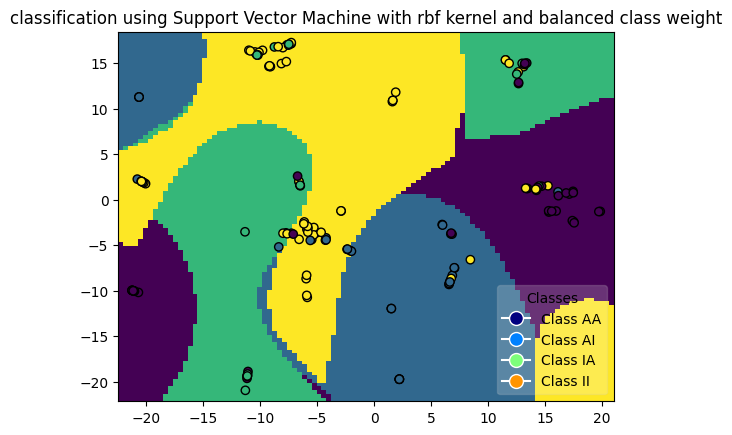

In [58]:
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors="k" , label= y_test)
class_labels = ['Class AA', 'Class AI', 'Class IA' , 'Class II']
handles = [plt.Line2D([0], [0], marker='o', color='w', label=class_labels[i], markerfacecolor=plt.cm.jet(i/len(class_labels)), markersize=10) for i in range(len(class_labels))]
plt.title("classification using Support Vector Machine with rbf kernel and balanced class weight")
plt.legend(handles=handles, title="Classes" , framealpha= 0.2)
plt.axis("tight")
plt.show()


### train on the whole dataset

In [59]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42 , probability=True)

In [62]:
clf.fit(X_reduced, y)

SVC(class_weight='balanced', probability=True, random_state=42)

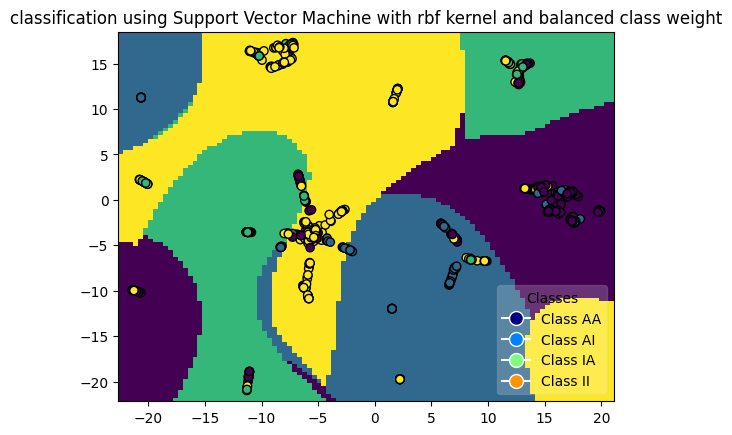

In [63]:
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_reduced,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, edgecolors="k" , label=y)
class_labels = ['Class AA', 'Class AI', 'Class IA' , 'Class II']
handles = [plt.Line2D([0], [0], marker='o', color='w', label=class_labels[i], markerfacecolor=plt.cm.jet(i/len(class_labels)), markersize=10) for i in range(len(class_labels))]
plt.legend(handles=handles , title="Classes" , framealpha= 0.2)
plt.title("classification using Support Vector Machine with rbf kernel and balanced class weight")
plt.axis("tight")
plt.show()


### but the figure with tsne was better

In [78]:
X_reduced = TSNE(random_state=42).fit_transform(X)

In [79]:
X_reduced

array([[  0.44940272, -24.452404  ],
       [-23.72359   ,  -7.5131435 ],
       [ -1.0644954 , -23.82095   ],
       ...,
       [-23.64101   ,  -8.3261385 ],
       [ -0.38524967,   4.171037  ],
       [ -0.21525514, -23.772568  ]], shape=(760, 2), dtype=float32)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced,y, stratify=y, random_state=42 , test_size=0.2)

In [81]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42, probability=True)

In [82]:
clf.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

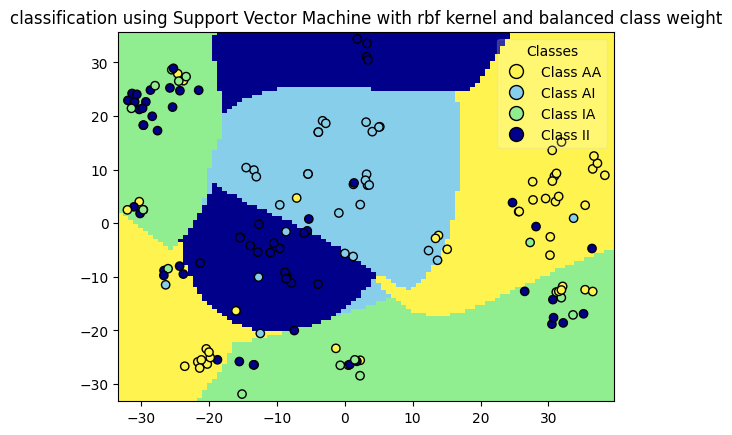

In [91]:
custom_colors = ["#FFF44F", "#87CEEB", "#90EE90", "#00008B"]  # lemon yellow, sky blue, light green, dark blue
class_labels = ['Class AA', 'Class AI', 'Class IA', 'Class II']
num_classes = len(class_labels)
cmap = ListedColormap(custom_colors)

ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
    cmap=cmap
)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,cmap=cmap, edgecolors="k" , label= y_test)
class_labels = ['Class AA', 'Class AI', 'Class IA' , 'Class II']
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        color='w',
        markerfacecolor=custom_colors[i],
        markeredgecolor='k',
        label=class_labels[i],
        markersize=10
    )
    for i in range(num_classes)
]
plt.title("classification using Support Vector Machine with rbf kernel and balanced class weight")
plt.legend(handles=handles, title="Classes" , framealpha= 0.2)
plt.axis("tight")
plt.show()


In [92]:
clf = svm.SVC(kernel="rbf" , class_weight="balanced" , random_state=42 , probability=True)

In [93]:
clf.fit(X_reduced, y)

SVC(class_weight='balanced', probability=True, random_state=42)

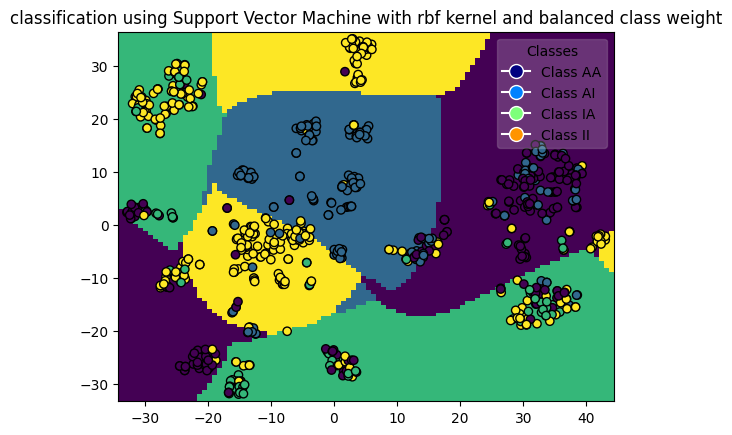

In [94]:
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_reduced,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, edgecolors="k" , label=y)
class_labels = ['Class AA', 'Class AI', 'Class IA' , 'Class II']
handles = [plt.Line2D([0], [0], marker='o', color='w', label=class_labels[i], markerfacecolor=plt.cm.jet(i/len(class_labels)), markersize=10) for i in range(len(class_labels))]
plt.legend(handles=handles , title="Classes" , framealpha= 0.2)
plt.title("classification using Support Vector Machine with rbf kernel and balanced class weight")
plt.axis("tight")
plt.show()


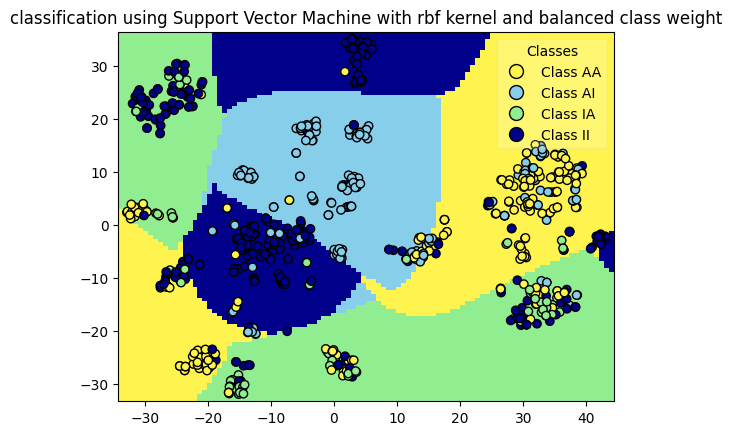

In [96]:
custom_colors = ["#FFF44F", "#87CEEB", "#90EE90", "#00008B"]  # lemon yellow, sky blue, light green, dark blue
class_labels = ['Class AA', 'Class AI', 'Class IA', 'Class II']
num_classes = len(class_labels)
cmap = ListedColormap(custom_colors)

ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_reduced,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
    cmap=cmap
)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y,cmap=cmap, edgecolors="k" , label= y_test)
class_labels = ['Class AA', 'Class AI', 'Class IA' , 'Class II']
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        color='w',
        markerfacecolor=custom_colors[i],
        markeredgecolor='k',
        label=class_labels[i],
        markersize=10
    )
    for i in range(num_classes)
]
plt.title("classification using Support Vector Machine with rbf kernel and balanced class weight")
plt.legend(handles=handles, title="Classes" , framealpha= 0.2)
plt.axis("tight")
plt.show()


### plotted with two color map. you choose which one is better.